# 15 — Bite2Text: EDA & Proxy Labeling IOTN-AC

Notebook ini mengeksplorasi dataset **Bite2Text** dan mengekstrak *proxy label*
IOTN-AC (1–10) dari caption klinis ortodontik yang tersedia.

**Apa itu proxy label?**
Dataset Bite2Text berisi ribuan foto intraoral + laporan klinis tertulis, tapi
*bukan* skor IOTN-AC. Dengan mem-parsing deskripsi klinis (crowding, overjet,
overbite, crossbite, dll.) kita bisa menghasilkan estimasi skor AC secara
otomatis — ini yang disebut *proxy label*. Hasilnya bisa langsung dipakai untuk
pretraining atau sebagai titik awal yang kemudian dikoreksi oleh ortodontis.

**Alur notebook:**

1. Setup & konfigurasi path
2. Eksplorasi struktur dataset Bite2Text
3. Parsing caption — ekstraksi fitur klinis
4. Rubrik penilaian — mapping fitur ke skor proxy AC
5. Analisis distribusi skor proxy
6. Perbandingan dengan dataset IOTN-AC yang sudah ada
7. Simpan hasil ke CSV

## Tahap 0 — Setup & Konfigurasi

In [1]:
import os, re, json, warnings
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from PIL import Image

warnings.filterwarnings("ignore", category=UserWarning)

# ── Deteksi root project ──────────────────────────────────────
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

# ── Path dataset — SESUAIKAN JIKA BERBEDA ─────────────────────
BITE2TEXT_DIR = Path.home() / "Downloads" / "Bite2Text"
IOTN_AC_DIR  = ROOT

# ── Output ─────────────────────────────────────────────────────
OUTPUT_DIR = ROOT / "outputs" / "bite2text_eda"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

assert BITE2TEXT_DIR.exists(), f"Folder Bite2Text tidak ditemukan di {BITE2TEXT_DIR}"

print(f"Project root  : {ROOT}")
print(f"Bite2Text dir : {BITE2TEXT_DIR}")
print(f"Output dir    : {OUTPUT_DIR}")

Project root  : /Users/rdrusdiati/IOTN-AC
Bite2Text dir : /Users/rdrusdiati/Downloads/Bite2Text
Output dir    : /Users/rdrusdiati/IOTN-AC/outputs/bite2text_eda


## Tahap 1 — Eksplorasi Struktur Dataset Bite2Text

Setiap kasus di Bite2Text tersimpan dalam folder `F####` yang berisi:

- `intraoral-photo/` — 5 foto JPG: frontal, left lateral, right lateral,
  mandibular occlusal, maxillary occlusal
- `ios/` — 3D scan (STL) rahang atas & bawah
- `reports_ios_en/` dan/atau `reports_intraoral-photo_en/` — laporan klinis
  dalam bahasa Inggris
- Varian bahasa Italia juga tersedia (tidak dipakai di sini)

In [2]:
# ── Scan semua folder kasus ────────────────────────────────────
case_dirs = sorted([
    d for d in BITE2TEXT_DIR.iterdir()
    if d.is_dir() and d.name.startswith("F")
])

print(f"Total kasus ditemukan : {len(case_dirs)}")
print(f"Rentang ID            : {case_dirs[0].name} – {case_dirs[-1].name}")

Total kasus ditemukan : 997
Rentang ID            : F1979 – F5535


In [3]:
# ── Periksa konsistensi struktur ───────────────────────────────
stats = defaultdict(int)

for case_dir in case_dirs:
    subdirs = {d.name for d in case_dir.iterdir() if d.is_dir()}
    photo_dir = case_dir / "intraoral-photo"

    n_photos = len(list(photo_dir.glob("*.jpg"))) if photo_dir.exists() else 0
    has_frontal = (photo_dir / "intraoral_1.jpg").exists()

    stats["total"]               += 1
    stats["punya_foto_frontal"]  += int(has_frontal)
    stats["punya_5_foto"]        += int(n_photos == 5)
    stats["punya_caption_photo"] += int("reports_intraoral-photo_en" in subdirs)
    stats["punya_caption_ios"]   += int("reports_ios_en" in subdirs)
    stats["punya_caption_any"]   += int(
        "reports_intraoral-photo_en" in subdirs or "reports_ios_en" in subdirs
    )

print("Statistik struktur dataset:\n")
for k, v in stats.items():
    pct = f"  ({v / stats['total'] * 100:.1f}%)" if k != "total" else ""
    print(f"  {k:25s}: {v:>5d}{pct}")

Statistik struktur dataset:

  total                    :   997
  punya_foto_frontal       :   932  (93.5%)
  punya_5_foto             :   836  (83.9%)
  punya_caption_photo      :   872  (87.5%)
  punya_caption_ios        :   991  (99.4%)
  punya_caption_any        :   996  (99.9%)


## Tahap 2 — Load Semua Caption

Beberapa kasus punya dua jenis caption:

- **`reports_intraoral-photo_en/`** — berdasarkan foto, lebih detail (menyebut
  karies, oral hygiene, dsb.)
- **`reports_ios_en/`** — berdasarkan intraoral scan, lebih fokus ke oklusi

Untuk proxy labeling, kita ambil **caption terpanjang** per kasus — ini biasanya
yang paling kaya informasi.

In [4]:
def load_best_caption(case_dir):
    """Load caption EN terpanjang dari satu kasus.
    Prioritas: ambil dari kedua sumber, pilih yang terpanjang.
    Return: (source_type, filename, text) atau None.
    """
    candidates = []
    for source in ["reports_intraoral-photo_en", "reports_ios_en"]:
        caption_dir = case_dir / source
        if caption_dir.exists():
            for txt_file in caption_dir.glob("*.txt"):
                text = txt_file.read_text(encoding="utf-8").strip()
                if text:
                    candidates.append((source, txt_file.name, text))

    if not candidates:
        return None

    # Pilih yang terpanjang
    return max(candidates, key=lambda x: len(x[2]))


# ── Load semua ─────────────────────────────────────────────────
captions = {}  # case_id -> (source, filename, text)

for case_dir in case_dirs:
    result = load_best_caption(case_dir)
    if result:
        captions[case_dir.name] = result

print(f"Kasus dengan caption : {len(captions)} / {len(case_dirs)}")
print(f"Tanpa caption        : {len(case_dirs) - len(captions)}")

# Distribusi sumber caption
source_counts = Counter(v[0] for v in captions.values())
print(f"\nSumber caption:")
for src, cnt in source_counts.most_common():
    print(f"  {src:40s}: {cnt}")

# Statistik panjang caption
lengths = [len(v[2]) for v in captions.values()]
print(f"\nPanjang caption (karakter):")
print(f"  Min: {min(lengths)},  Median: {int(np.median(lengths))},  Max: {max(lengths)}")

Kasus dengan caption : 996 / 997
Tanpa caption        : 1

Sumber caption:
  reports_intraoral-photo_en              : 850
  reports_ios_en                          : 146

Panjang caption (karakter):
  Min: 332,  Median: 715,  Max: 1623


## Tahap 3 — Contoh Kasus: Foto + Caption

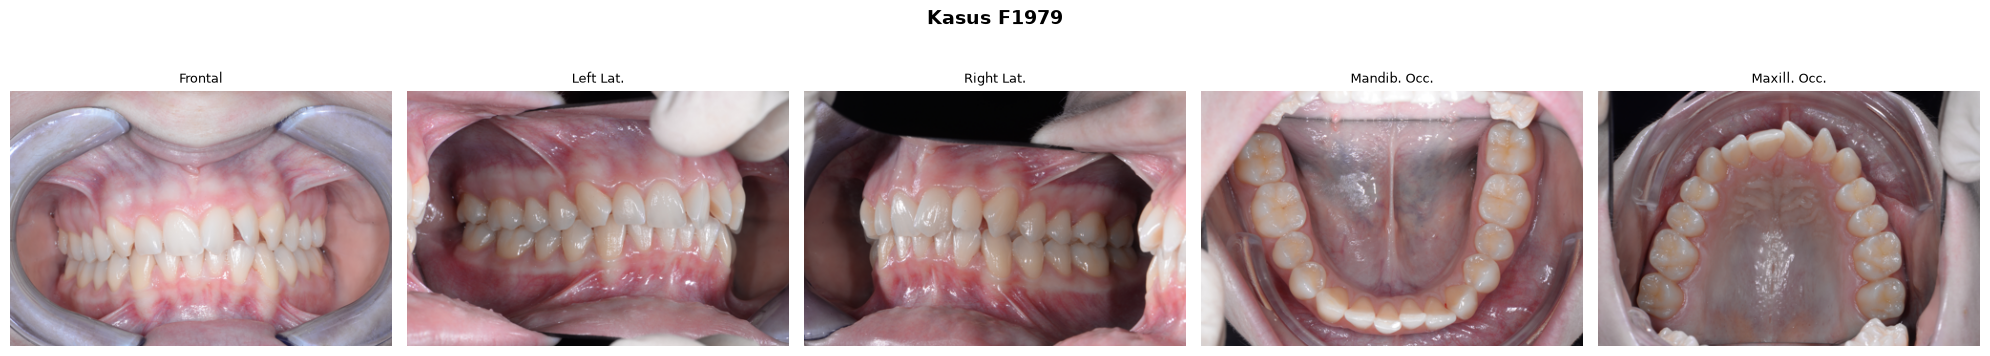

  Caption (reports_ios_en/12_2319.txt):
  The patient presents a slight constriction of the maxilla in the absence of crossbite. From a vertical standpoint, there is a deep bite. Sagittally, there is a weak Class I molar relationship and an edge-to-edge Class II canine relationship on the right, and a full Class II molar and canine relationship on the left with increased overjet. The midlines are centered with each other. The Curve of Spee and the Curve of Wilson are increased. There is moderate crowding in the upper arch and mild crowding in the lower arch.



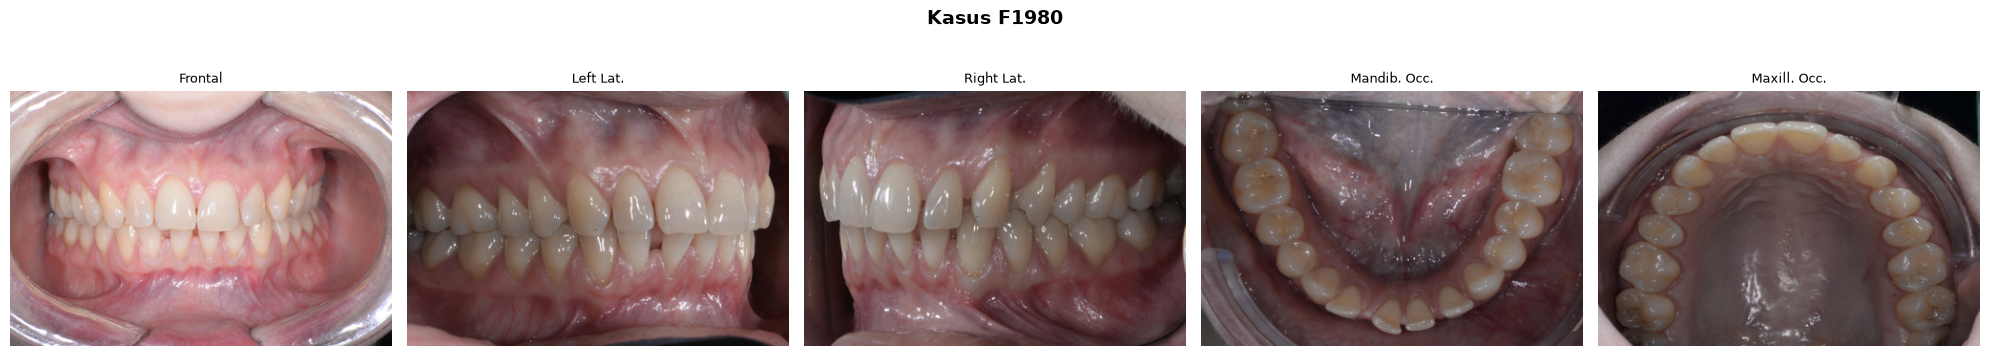

  Caption (reports_ios_en/12_2320.txt):
  The patient presents correct transverse and vertical relationships. Sagittally, there is an end-to-end Class II molar relationship and a full Class II canine relationship on the right, and a Class I molar relationship and an end-to-end Class II canine relationship on the left, with overjet within normal limits. The dental midlines are coincident. The Curve of Spee and the Curve of Wilson are within normal limits. No crowding is present in the upper and lower arches, with the presence of spaces in both arches.



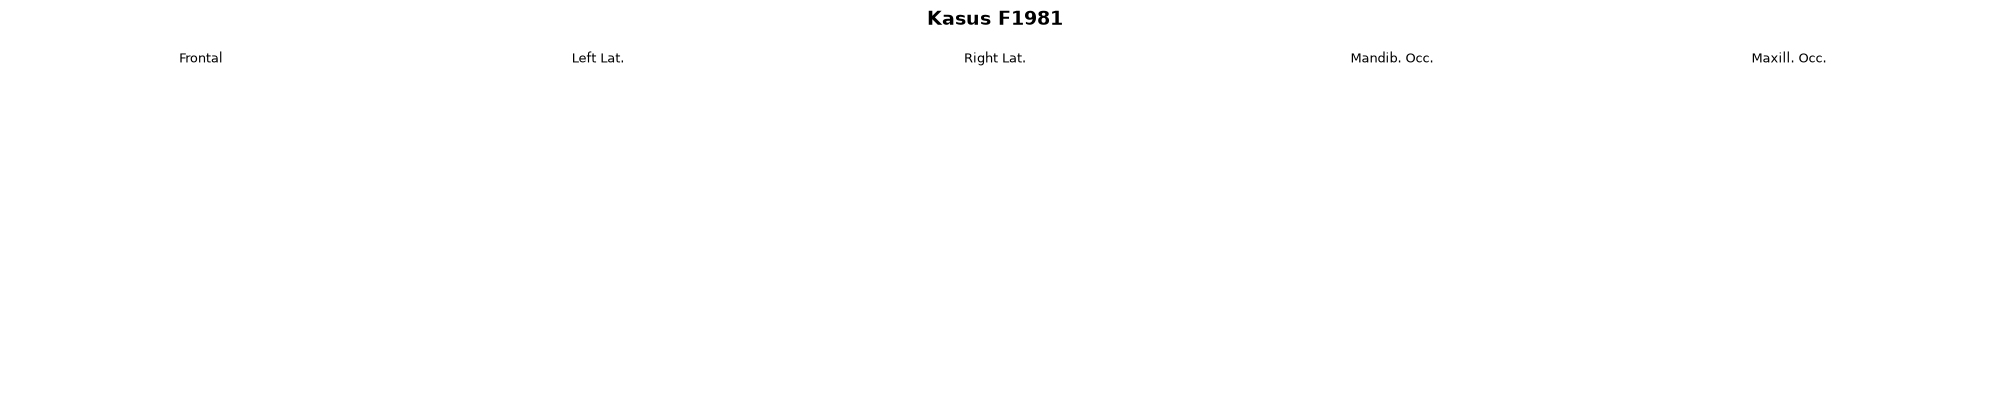

  Caption (reports_intraoral-photo_en/12_2989.txt):
  The patient presents with a transverse constriction of the maxilla in the absence of crossbite. Sagittally, there is a full Class II molar and canine relationship, while on the left the molar class cannot be assessed due to the absence of tooth 26, and the canine is in full Class II. Overjet is increased. The dental midlines are deviated relative to each other. The Curve of Spee and the Curve of Wilson are increased. No crowding is present in the upper and lower arches, with the presence of spaces in the lower arch. Restorations are present on teeth 16-15-36-45-46-47.



In [5]:
# ── Tampilkan 3 contoh kasus ──────────────────────────────────
sample_ids = list(captions.keys())[:3]
view_names = ["Frontal", "Left Lat.", "Right Lat.", "Mandib. Occ.", "Maxill. Occ."]

for case_id in sample_ids:
    fig, axes = plt.subplots(1, 5, figsize=(20, 4))
    fig.suptitle(f"Kasus {case_id}", fontsize=14, fontweight="bold")

    for i, (ax, vname) in enumerate(zip(axes, view_names)):
        img_path = BITE2TEXT_DIR / case_id / "intraoral-photo" / f"intraoral_{i+1}.jpg"
        if img_path.exists():
            img = Image.open(img_path).resize((400, 267))
            ax.imshow(img)
        ax.set_title(vname, fontsize=9)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

    source, fname, text = captions[case_id]
    print(f"  Caption ({source}/{fname}):")
    print(f"  {text}\n")

## Tahap 4 — Parsing Fitur Klinis dari Caption

Parser mengekstrak fitur-fitur berikut dari teks caption:

| Fitur | Nilai yang mungkin |
|---|---|
| `crowding_upper` | none / mild / moderate / moderate-to-severe / severe |
| `crowding_lower` | none / mild / moderate / moderate-to-severe / severe |
| `crowding_worst` | (otomatis: maks dari upper & lower) |
| `overbite` | normal / increased / open_bite / reduced / edge_to_edge |
| `overjet` | normal / increased / reverse |
| `crossbite` | absent / present / anterior / posterior |
| `angle_class` | I / II_end_to_end / II / II_full / III / unknown |
| `midline` | centered / slightly_deviated / deviated / unknown |
| `has_spacing` | True / False |
| `has_displacement` | True / False |
| `has_open_bite` | True / False |

In [6]:
def parse_caption(text):
    """Ekstrak fitur klinis dari caption Bite2Text."""
    t = text.lower()
    features = {}

    # ── CROWDING ───────────────────────────────────────────────
    severity_map = [
        ("severe",             "severe"),
        ("moderate-to-severe", "moderate-to-severe"),
        ("moderate to severe", "moderate-to-severe"),
        ("moderate",           "moderate"),
        ("mild",               "mild"),
    ]

    def find_crowding_arch(arch_keyword):
        """Cari severity crowding untuk arch tertentu (proximity match)."""
        for pattern, label in severity_map:
            # "moderate crowding in the upper arch"
            if re.search(rf"{pattern}\s+crowding\s+in\s+(?:the\s+)?(?:both\s+)?{arch_keyword}", t):
                return label
            # "moderate crowding of the upper arch"
            if re.search(rf"{pattern}\s+crowding\s+of\s+(?:the\s+)?{arch_keyword}", t):
                return label
            # "upper arch shows moderate crowding"
            if re.search(rf"{arch_keyword}\s+arch.{{0,30}}{pattern}\s+crowding", t):
                return label
        return None

    # Step 1 — Cek pola gabungan dulu: "mild crowding in both/upper and lower arches"
    cu = None
    cl = None
    for pattern, label in severity_map:
        if re.search(rf"{pattern}\s+crowding\s+in\s+(?:the\s+)?(?:both|upper\s+and\s+lower|lower\s+and\s+upper)", t):
            cu = cl = label
            break

    # Step 2 — Per-arch specific (bisa override pola gabungan)
    cu_specific = find_crowding_arch("upper")
    cl_specific = find_crowding_arch("lower")
    if cu_specific:
        cu = cu_specific
    if cl_specific:
        cl = cl_specific

    # Step 3 — Fallback: general "moderate crowding" tanpa arch
    if cu is None and cl is None:
        for pattern, label in severity_map:
            if re.search(rf"{pattern}\s+crowding", t):
                cu = cl = label
                break

    # "no crowding" / "absence of crowding"
    if re.search(r"(?:no|absence of|without)\s+crowding", t):
        cu = cu or "none"
        cl = cl or "none"

    features["crowding_upper"] = cu or "none"
    features["crowding_lower"] = cl or "none"

    sev_order = {"none": 0, "mild": 1, "moderate": 2, "moderate-to-severe": 3, "severe": 4}
    features["crowding_worst"] = max(
        features["crowding_upper"], features["crowding_lower"],
        key=lambda x: sev_order.get(x, 0)
    )

    # ── OVERBITE ───────────────────────────────────────────────
    # Gunakan [^.]* agar regex tidak melewati batas kalimat
    if re.search(r"open\s*bite", t):
        features["overbite"] = "open_bite"
    elif re.search(r"deep\s*bite", t) or re.search(r"overbite[^.]*increased|increased[^.]*overbite", t):
        features["overbite"] = "increased"
    elif re.search(r"overbite[^.]*reduced|reduced[^.]*overbite", t):
        features["overbite"] = "reduced"
    elif re.search(r"edge[\s\-]+to[\s\-]+edge[^.]*(?:incisal|bite|relationship)", t):
        features["overbite"] = "edge_to_edge"
    else:
        features["overbite"] = "normal"

    # ── OVERJET ────────────────────────────────────────────────
    if re.search(r"reverse\s+overjet|negative\s+overjet", t):
        features["overjet"] = "reverse"
    elif re.search(r"(?:increased|excessive)\s+overjet|overjet[^.]*increased", t):
        features["overjet"] = "increased"
    else:
        features["overjet"] = "normal"

    # ── CROSSBITE ──────────────────────────────────────────────
    # Urutan: cek konteks positif spesifik dulu, lalu negasi
    if re.search(r"crossbite\s+involving|crossbite\s+on|with\s+crossbite", t):
        features["crossbite"] = "present"
    elif re.search(r"posterior\s+crossbite", t):
        features["crossbite"] = "posterior"
    elif re.search(r"anterior\s+crossbite", t):
        features["crossbite"] = "anterior"
    elif re.search(r"(?:absence|without|no)\s+(?:of\s+)?(?:posterior\s+)?crossbite", t):
        features["crossbite"] = "absent"
    elif re.search(r"crossbite", t):
        features["crossbite"] = "present"
    else:
        features["crossbite"] = "absent"

    # ── ANGLE CLASSIFICATION ───────────────────────────────────
    has_iii      = bool(re.search(r"class\s+iii", t))
    has_ii_full  = bool(re.search(r"full\s+class\s+ii|class\s+ii.*full", t))
    has_ii_end   = bool(re.search(r"end[\s\-]+to[\s\-]+end.*class\s+ii|class\s+ii.*end[\s\-]+to[\s\-]+end", t))
    has_ii       = bool(re.search(r"class\s+ii", t))
    has_i        = bool(re.search(r"class\s+i(?!i)\b", t))

    if has_iii:
        features["angle_class"] = "III"
    elif has_ii_full:
        features["angle_class"] = "II_full"
    elif has_ii_end:
        features["angle_class"] = "II_end_to_end"
    elif has_ii:
        features["angle_class"] = "II"
    elif has_i:
        features["angle_class"] = "I"
    else:
        features["angle_class"] = "unknown"

    # ── MIDLINE ────────────────────────────────────────────────
    if re.search(r"midline.*(?:are\s+)?(?:centered|coincident|centred)", t):
        features["midline"] = "centered"
    elif re.search(r"midline.*(?:slightly|mildly)\s+deviat", t):
        features["midline"] = "slightly_deviated"
    elif re.search(r"midline.*deviat", t):
        features["midline"] = "deviated"
    else:
        features["midline"] = "unknown"

    # ── SPACING ────────────────────────────────────────────────
    features["has_spacing"] = bool(re.search(r"\bspacing\b|diastema|\bspaced\b", t))

    # ── DISPLACEMENT / ECTOPIC ─────────────────────────────────
    features["has_displacement"] = bool(re.search(
        r"ectopic|displace|labio[\s\-]?version|palato[\s\-]?version|"
        r"linguo[\s\-]?version|rotat(?:ed|ion)|tipp(?:ed|ing)|"
        r"impacted|transpos|supernumerar",
        t
    ))

    # ── OPEN BITE ──────────────────────────────────────────────
    features["has_open_bite"] = bool(re.search(r"open\s*bite", t))

    # ── CONSTRICTION ───────────────────────────────────────────
    features["has_constriction"] = bool(re.search(r"constrict", t))

    return features


# ── Test parser pada contoh caption ────────────────────────────
for case_id in sample_ids:
    _, _, text = captions[case_id]
    feat = parse_caption(text)
    print(f"=== {case_id} ===")
    for k, v in feat.items():
        print(f"  {k:22s}: {v}")
    print()

=== F1979 ===
  crowding_upper        : moderate
  crowding_lower        : mild
  crowding_worst        : moderate
  overbite              : increased
  overjet               : increased
  crossbite             : absent
  angle_class           : II_full
  midline               : centered
  has_spacing           : False
  has_displacement      : False
  has_open_bite         : False
  has_constriction      : True

=== F1980 ===
  crowding_upper        : none
  crowding_lower        : none
  crowding_worst        : none
  overbite              : normal
  overjet               : normal
  crossbite             : absent
  angle_class           : II_full
  midline               : centered
  has_spacing           : False
  has_displacement      : False
  has_open_bite         : False
  has_constriction      : False

=== F1981 ===
  crowding_upper        : none
  crowding_lower        : none
  crowding_worst        : none
  overbite              : normal
  overjet               : increased
  c

## Tahap 5 — Parse Semua Caption & Statistik Fitur

In [7]:
# ── Parse semua caption ────────────────────────────────────────
parsed = {}
for case_id, (source, fname, text) in captions.items():
    parsed[case_id] = parse_caption(text)

df_features = pd.DataFrame.from_dict(parsed, orient="index")
df_features.index.name = "case_id"

print(f"Total kasus ter-parse: {len(df_features)}")
print(f"\nDistribusi tiap fitur:\n")

for col in df_features.columns:
    print(f"─── {col} ───")
    vc = df_features[col].value_counts()
    for val, cnt in vc.items():
        pct = cnt / len(df_features) * 100
        print(f"  {str(val):25s}: {cnt:>5d}  ({pct:.1f}%)")
    print()

Total kasus ter-parse: 996

Distribusi tiap fitur:

─── crowding_upper ───
  none                     :   455  (45.7%)
  mild                     :   301  (30.2%)
  moderate                 :   148  (14.9%)
  severe                   :    91  (9.1%)
  moderate-to-severe       :     1  (0.1%)

─── crowding_lower ───
  none                     :   445  (44.7%)
  mild                     :   332  (33.3%)
  moderate                 :   132  (13.3%)
  severe                   :    87  (8.7%)

─── crowding_worst ───
  none                     :   423  (42.5%)
  mild                     :   322  (32.3%)
  moderate                 :   153  (15.4%)
  severe                   :    98  (9.8%)

─── overbite ───
  increased                :   499  (50.1%)
  normal                   :   231  (23.2%)
  open_bite                :   124  (12.4%)
  reduced                  :    85  (8.5%)
  edge_to_edge             :    57  (5.7%)

─── overjet ───
  increased                :   517  (51.9%)
  normal    

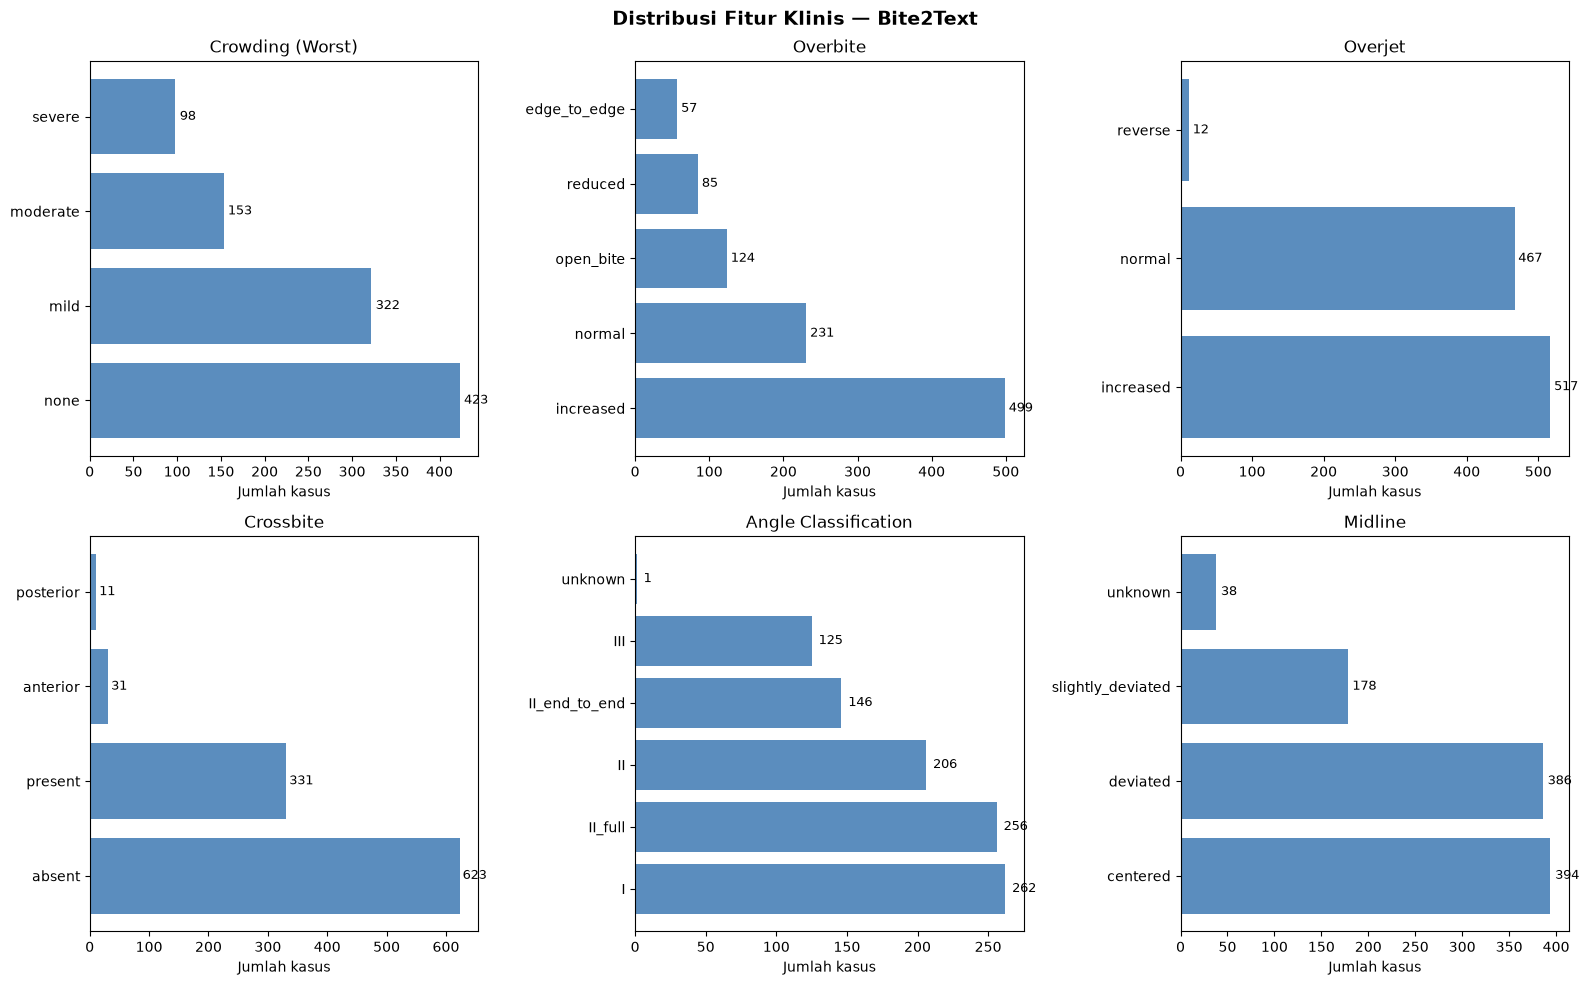

Tersimpan: /Users/rdrusdiati/IOTN-AC/outputs/bite2text_eda/distribusi_fitur_klinis.png


In [8]:
# ── Visualisasi distribusi fitur utama ─────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Distribusi Fitur Klinis — Bite2Text", fontsize=14, fontweight="bold")

plot_cols = [
    ("crowding_worst", "Crowding (Worst)"),
    ("overbite", "Overbite"),
    ("overjet", "Overjet"),
    ("crossbite", "Crossbite"),
    ("angle_class", "Angle Classification"),
    ("midline", "Midline"),
]

for ax, (col, title) in zip(axes.flat, plot_cols):
    vc = df_features[col].value_counts()
    bars = ax.barh(vc.index.astype(str), vc.values, color="#5B8DBE")
    ax.set_title(title)
    ax.set_xlabel("Jumlah kasus")
    for bar, val in zip(bars, vc.values):
        ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
                f"{val}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "distribusi_fitur_klinis.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Tersimpan: {OUTPUT_DIR / 'distribusi_fitur_klinis.png'}")

## Tahap 6 — Rubrik Proxy Scoring IOTN-AC

### Bagaimana mapping fitur → skor AC?

Setiap fitur diberi bobot berdasarkan dampak estetiknya pada tampilan frontal.
Total poin mentah kemudian dipetakan secara linear ke skala 1–10.

> **Penting:** rubrik ini adalah *estimasi heuristik*, bukan penilaian klinis.
> Nilainya bisa disesuaikan di dict `RUBRIC` di bawah. Idealnya, sampel hasil
> proxy label divalidasi oleh ortodontis.

In [9]:
# ── Rubrik penilaian ───────────────────────────────────────────
# Setiap fitur → bobot poin.
# Total poin mentah akan dipetakan ke skala 1–10.

RUBRIC = {
    "crowding_worst": {
        "none": 0, "mild": 1.0, "moderate": 2.5,
        "moderate-to-severe": 3.5, "severe": 5.0,
    },
    "overbite": {
        "normal": 0, "reduced": 0.5, "edge_to_edge": 0.5,
        "increased": 1.5, "open_bite": 2.5,
    },
    "overjet": {
        "normal": 0, "increased": 2.5, "reverse": 3.0,
    },
    "crossbite": {
        "absent": 0, "present": 2.0, "anterior": 2.5, "posterior": 1.5,
    },
    "angle_class": {
        "I": 0, "II_end_to_end": 0.5, "II": 1.0,
        "II_full": 1.5, "III": 2.0, "unknown": 0,
    },
    "midline": {
        "centered": 0, "slightly_deviated": 0.25,
        "deviated": 0.5, "unknown": 0,
    },
    "has_spacing":      {True: 0.5, False: 0},
    "has_displacement":  {True: 2.0, False: 0},
    "has_open_bite":     {True: 2.0, False: 0},  # tambahan di atas overbite
    "has_constriction":  {True: 0.5, False: 0},
}

# Hitung batas maksimum teoritis
max_raw = sum(max(v.values()) for v in RUBRIC.values())
print(f"Skor mentah maksimum teoritis: {max_raw}")
print(f"\nRubrik aktif:")
for feat, mapping in RUBRIC.items():
    print(f"  {feat}:")
    for val, pts in mapping.items():
        if pts > 0:
            print(f"    {str(val):25s} → +{pts}")

Skor mentah maksimum teoritis: 20.5

Rubrik aktif:
  crowding_worst:
    mild                      → +1.0
    moderate                  → +2.5
    moderate-to-severe        → +3.5
    severe                    → +5.0
  overbite:
    reduced                   → +0.5
    edge_to_edge              → +0.5
    increased                 → +1.5
    open_bite                 → +2.5
  overjet:
    increased                 → +2.5
    reverse                   → +3.0
  crossbite:
    present                   → +2.0
    anterior                  → +2.5
    posterior                 → +1.5
  angle_class:
    II_end_to_end             → +0.5
    II                        → +1.0
    II_full                   → +1.5
    III                       → +2.0
  midline:
    slightly_deviated         → +0.25
    deviated                  → +0.5
  has_spacing:
    True                      → +0.5
  has_displacement:
    True                      → +2.0
  has_open_bite:
    True                      → +2.0
  

In [10]:
def compute_proxy_score(features, rubric=RUBRIC, max_raw_override=None):
    """Hitung proxy IOTN-AC score (1–10) dari fitur yang ter-parse.

    Mapping: linear dari skor mentah ke skala 1–10.
    - raw = 0      → grade 1 (ideal)
    - raw = max_raw → grade 10 (paling berat)
    """
    raw = 0.0
    breakdown = {}

    for feat, mapping in rubric.items():
        val = features.get(feat)
        pts = mapping.get(val, 0)
        raw += pts
        if pts > 0:
            breakdown[feat] = (val, pts)

    # Petakan ke 1–10
    mr = max_raw_override or sum(max(v.values()) for v in rubric.values())
    score = 1 + (raw / mr) * 9
    grade = int(np.clip(np.round(score), 1, 10))

    return grade, raw, breakdown


# ── Test pada contoh ───────────────────────────────────────────
for case_id in sample_ids:
    feat = parsed[case_id]
    grade, raw, breakdown = compute_proxy_score(feat)
    print(f"=== {case_id}: Grade {grade}  (raw={raw:.1f}) ===")
    for f, (val, pts) in breakdown.items():
        print(f"  +{pts:.1f}  ← {f} = {val}")
    print()

=== F1979: Grade 5  (raw=8.5) ===
  +2.5  ← crowding_worst = moderate
  +1.5  ← overbite = increased
  +2.5  ← overjet = increased
  +1.5  ← angle_class = II_full
  +0.5  ← has_constriction = True

=== F1980: Grade 2  (raw=1.5) ===
  +1.5  ← angle_class = II_full

=== F1981: Grade 3  (raw=5.0) ===
  +2.5  ← overjet = increased
  +1.5  ← angle_class = II_full
  +0.5  ← midline = deviated
  +0.5  ← has_constriction = True



## Tahap 7 — Generate Proxy Label untuk Semua Kasus

In [11]:
# ── Hitung proxy score untuk semua kasus ───────────────────────
results = []

for case_id in sorted(parsed.keys()):
    feat = parsed[case_id]
    grade, raw, breakdown = compute_proxy_score(feat)

    frontal_path = BITE2TEXT_DIR / case_id / "intraoral-photo" / "intraoral_1.jpg"

    results.append({
        "case_id": case_id,
        "proxy_grade_ac": grade,
        "raw_score": round(raw, 2),
        "frontal_exists": frontal_path.exists(),
        "caption_source": captions[case_id][0],
        "crowding_worst": feat["crowding_worst"],
        "overbite": feat["overbite"],
        "overjet": feat["overjet"],
        "crossbite": feat["crossbite"],
        "angle_class": feat["angle_class"],
        "midline": feat["midline"],
        "has_spacing": feat["has_spacing"],
        "has_displacement": feat["has_displacement"],
        "has_open_bite": feat["has_open_bite"],
        "has_constriction": feat["has_constriction"],
        "caption_text": captions[case_id][2],
    })

df_proxy = pd.DataFrame(results)
print(f"Total kasus dengan proxy label: {len(df_proxy)}")
print(f"Kasus dengan foto frontal     : {df_proxy['frontal_exists'].sum()}")

print(f"\nDistribusi proxy Grade AC:")
print(df_proxy["proxy_grade_ac"].value_counts().sort_index().to_string())

Total kasus dengan proxy label: 996
Kasus dengan foto frontal     : 931

Distribusi proxy Grade AC:
proxy_grade_ac
1     70
2    112
3    256
4    277
5    179
6     78
7     18
8      5
9      1


## Tahap 8 — Analisis Distribusi Proxy Label

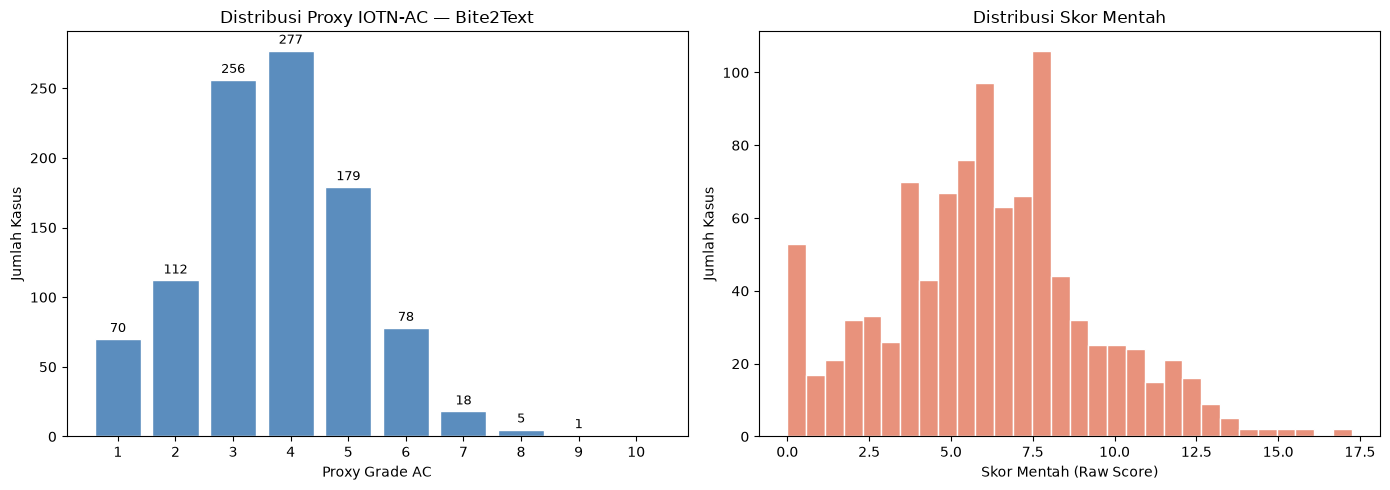

Tersimpan: /Users/rdrusdiati/IOTN-AC/outputs/bite2text_eda/distribusi_proxy_grade.png


In [12]:
# ── Histogram proxy grade ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
ax = axes[0]
counts = df_proxy["proxy_grade_ac"].value_counts().sort_index()
all_grades = range(1, 11)
heights = [counts.get(g, 0) for g in all_grades]
bars = ax.bar(all_grades, heights, color="#5B8DBE", edgecolor="white")
ax.set_xlabel("Proxy Grade AC")
ax.set_ylabel("Jumlah Kasus")
ax.set_title("Distribusi Proxy IOTN-AC — Bite2Text")
ax.set_xticks(range(1, 11))
for bar, h in zip(bars, heights):
    if h > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                str(h), ha="center", fontsize=9)

# Raw score histogram
ax = axes[1]
ax.hist(df_proxy["raw_score"], bins=30, color="#E8927C", edgecolor="white")
ax.set_xlabel("Skor Mentah (Raw Score)")
ax.set_ylabel("Jumlah Kasus")
ax.set_title("Distribusi Skor Mentah")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "distribusi_proxy_grade.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Tersimpan: {OUTPUT_DIR / 'distribusi_proxy_grade.png'}")

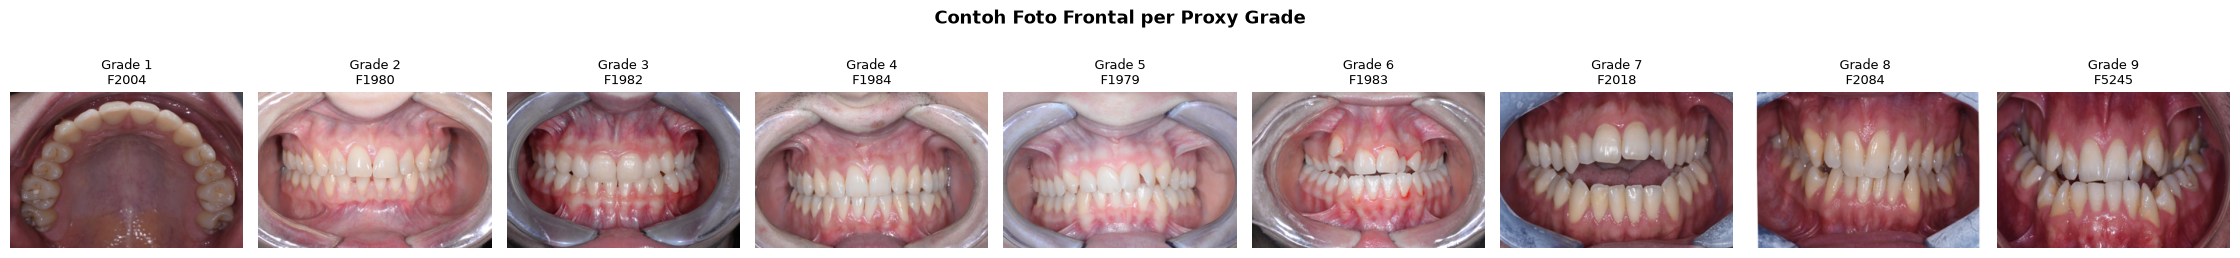

Tersimpan: /Users/rdrusdiati/IOTN-AC/outputs/bite2text_eda/contoh_per_grade.png


In [13]:
# ── Contoh kasus per grade ─────────────────────────────────────
# Tampilkan 1 foto frontal per grade yang ada

available_grades = sorted(df_proxy["proxy_grade_ac"].unique())
n_grades = len(available_grades)

fig, axes = plt.subplots(1, min(n_grades, 10), figsize=(min(n_grades, 10) * 2.5, 3))
if n_grades == 1:
    axes = [axes]
fig.suptitle("Contoh Foto Frontal per Proxy Grade", fontsize=13, fontweight="bold")

for ax, grade in zip(axes, available_grades):
    # Ambil kasus pertama dengan grade ini yang punya foto frontal
    subset = df_proxy[(df_proxy["proxy_grade_ac"] == grade) & (df_proxy["frontal_exists"])]
    if subset.empty:
        ax.set_title(f"Grade {grade}\n(n/a)")
        ax.axis("off")
        continue

    row = subset.iloc[0]
    img_path = BITE2TEXT_DIR / row["case_id"] / "intraoral-photo" / "intraoral_1.jpg"
    img = Image.open(img_path).resize((300, 200))
    ax.imshow(img)
    ax.set_title(f"Grade {grade}\n{row['case_id']}", fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "contoh_per_grade.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Tersimpan: {OUTPUT_DIR / 'contoh_per_grade.png'}")

## Tahap 9 — Perbandingan dengan Dataset IOTN-AC yang Ada

Bandingkan distribusi proxy label Bite2Text dengan label asli di dataset
IOTN-AC (dari `data/labels/Grade AC by Team.xlsx`) untuk melihat apakah
distribusinya mirip atau perlu di-rebalance.

In [14]:
# ── Load label IOTN-AC yang ada ────────────────────────────────
label_path = IOTN_AC_DIR / "data" / "labels" / "Grade AC by Team.xlsx"
if label_path.exists():
    dfs_existing = {}
    for sheet in ["Train", "Val", "Test"]:
        df_sheet = pd.read_excel(label_path, sheet_name=sheet)
        dfs_existing[sheet] = df_sheet

    df_existing = pd.concat(dfs_existing.values(), ignore_index=True)

    # Kolom annotator: Claude Opus 5, Nana, Anin, Nico
    annotator_cols = [c for c in df_existing.columns
                      if c in ["Claude Opus 5", "Nana", "Anin", "Nico"]]

    # Hitung mean grade per foto
    df_existing["mean_grade"] = df_existing[annotator_cols].mean(axis=1).round().astype(int)
    df_existing["mean_grade"] = df_existing["mean_grade"].clip(1, 10)

    print(f"Dataset IOTN-AC yang ada:")
    print(f"  Total foto        : {len(df_existing)}")
    print(f"  Annotator         : {annotator_cols}")
    print(f"  Distribusi mean grade:")
    print(df_existing["mean_grade"].value_counts().sort_index().to_string())
else:
    print("File label IOTN-AC tidak ditemukan — skip perbandingan.")
    df_existing = None

Dataset IOTN-AC yang ada:
  Total foto        : 555
  Annotator         : ['Claude Opus 5', 'Nana', 'Anin', 'Nico']
  Distribusi mean grade:
mean_grade
1      10
2     106
3      42
4      80
5      62
6     127
7      64
8      39
9      19
10      6


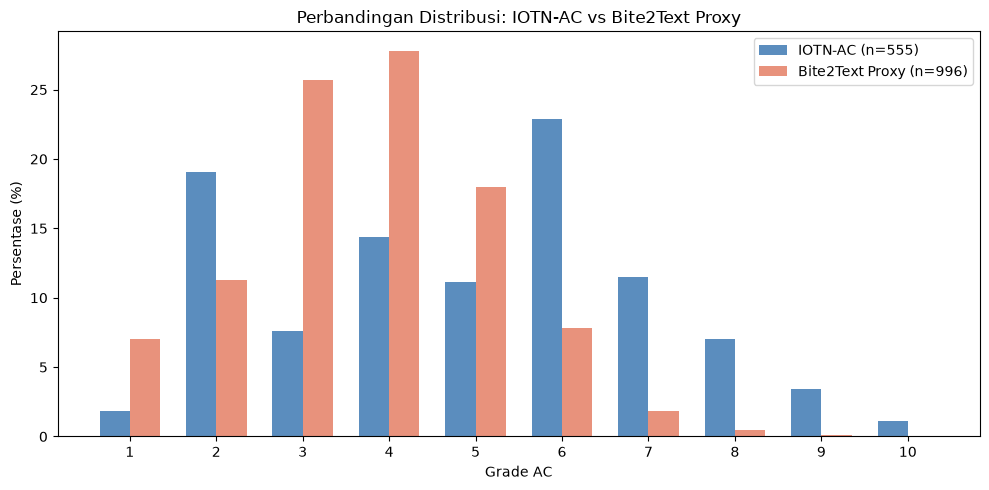

Tersimpan: /Users/rdrusdiati/IOTN-AC/outputs/bite2text_eda/perbandingan_distribusi.png


In [15]:
# ── Plot perbandingan distribusi ───────────────────────────────
if df_existing is not None:
    fig, ax = plt.subplots(figsize=(10, 5))

    grades = range(1, 11)

    # IOTN-AC existing
    existing_counts = df_existing["mean_grade"].value_counts().sort_index()
    existing_pct = [(existing_counts.get(g, 0) / len(df_existing) * 100) for g in grades]

    # Bite2Text proxy
    proxy_counts = df_proxy["proxy_grade_ac"].value_counts().sort_index()
    proxy_pct = [(proxy_counts.get(g, 0) / len(df_proxy) * 100) for g in grades]

    x = np.arange(len(grades))
    w = 0.35

    bars1 = ax.bar(x - w/2, existing_pct, w, label=f"IOTN-AC (n={len(df_existing)})", color="#5B8DBE")
    bars2 = ax.bar(x + w/2, proxy_pct, w, label=f"Bite2Text Proxy (n={len(df_proxy)})", color="#E8927C")

    ax.set_xlabel("Grade AC")
    ax.set_ylabel("Persentase (%)")
    ax.set_title("Perbandingan Distribusi: IOTN-AC vs Bite2Text Proxy")
    ax.set_xticks(x)
    ax.set_xticklabels(grades)
    ax.legend()

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "perbandingan_distribusi.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Tersimpan: {OUTPUT_DIR / 'perbandingan_distribusi.png'}")
else:
    print("Skip — data IOTN-AC tidak tersedia.")

## Tahap 10 — Simpan Hasil

In [16]:
# ── Simpan ke CSV ──────────────────────────────────────────────
# Versi lengkap (dengan caption text)
output_full = OUTPUT_DIR / "bite2text_proxy_labels_full.csv"
df_proxy.to_csv(output_full, index=False)
print(f"CSV lengkap  : {output_full}")
print(f"  Baris: {len(df_proxy)}, Kolom: {len(df_proxy.columns)}")

# Versi ringkas (tanpa caption text, untuk training)
cols_compact = [
    "case_id", "proxy_grade_ac", "raw_score", "frontal_exists",
    "crowding_worst", "overbite", "overjet", "crossbite",
    "angle_class", "has_displacement", "has_open_bite",
]
output_compact = OUTPUT_DIR / "bite2text_proxy_labels.csv"
df_proxy[cols_compact].to_csv(output_compact, index=False)
print(f"\nCSV ringkas  : {output_compact}")
print(f"  Baris: {len(df_proxy)}, Kolom: {len(cols_compact)}")

CSV lengkap  : /Users/rdrusdiati/IOTN-AC/outputs/bite2text_eda/bite2text_proxy_labels_full.csv
  Baris: 996, Kolom: 16

CSV ringkas  : /Users/rdrusdiati/IOTN-AC/outputs/bite2text_eda/bite2text_proxy_labels.csv
  Baris: 996, Kolom: 11


In [17]:
# ── Ringkasan akhir ────────────────────────────────────────────
usable = df_proxy[df_proxy["frontal_exists"]]
print("=" * 60)
print("RINGKASAN")
print("=" * 60)
print(f"Total kasus Bite2Text ter-parse : {len(df_proxy):>6d}")
print(f"Kasus dengan foto frontal       : {len(usable):>6d}")
print(f"Proxy grade range               : {usable['proxy_grade_ac'].min()} – {usable['proxy_grade_ac'].max()}")
print(f"Proxy grade median              : {usable['proxy_grade_ac'].median():.0f}")
print()
print("Data ini bisa digunakan untuk:")
print("  1. Pretraining model AC pada dataset besar sebelum fine-tune ke data IOTN-AC")
print("  2. Augmentasi data training — gabungkan dengan dataset IOTN-AC yang sudah ada")
print("  3. Review manual — ortodontis koreksi proxy label (lebih cepat dari labeling nol)")
print()
print(f"Output tersimpan di: {OUTPUT_DIR}")

RINGKASAN
Total kasus Bite2Text ter-parse :    996
Kasus dengan foto frontal       :    931
Proxy grade range               : 1 – 9
Proxy grade median              : 4

Data ini bisa digunakan untuk:
  1. Pretraining model AC pada dataset besar sebelum fine-tune ke data IOTN-AC
  2. Augmentasi data training — gabungkan dengan dataset IOTN-AC yang sudah ada
  3. Review manual — ortodontis koreksi proxy label (lebih cepat dari labeling nol)

Output tersimpan di: /Users/rdrusdiati/IOTN-AC/outputs/bite2text_eda
